In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from obspy import Inventory, UTCDateTime, read
from obspy.clients.fdsn import Client
dpath = '/Users/oxide/Documents/research/orenstein/code/P288FinalProject/alex/data/'
processed_dpath = '/Users/oxide/Documents/research/orenstein/code/P288FinalProject/alex/processed_data/'

def deduplicate_datetime_index(df, strategy='first'):
    """
    Remove duplicate timestamps from a DataFrame, handling both numeric and non-numeric data.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with DatetimeIndex that may contain duplicates
    strategy : str or dict
        How to handle duplicates:
        - 'first': Keep first occurrence (default)
        - 'last': Keep last occurrence
        - 'mean': Average numeric columns, first for non-numeric
        - 'median': Median for numeric, first for non-numeric
        - dict: Column-specific strategies, e.g., {'col1': 'mean', 'col2': 'first'}
    
    Returns
    -------
    pd.DataFrame
        DataFrame with unique timestamps
    """
    if not df.index.has_duplicates:
        return df.copy()
    
    if strategy == 'first':
        return df[~df.index.duplicated(keep='first')]
    
    elif strategy == 'last':
        return df[~df.index.duplicated(keep='last')]
    
    elif strategy in ['mean', 'median']:
        # Group by index and apply appropriate aggregation
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
        
        result_parts = []
        
        # Handle numeric columns
        if len(numeric_cols) > 0:
            if strategy == 'mean':
                numeric_agg = df[numeric_cols].groupby(level=0).mean()
            else:  # median
                numeric_agg = df[numeric_cols].groupby(level=0).median()
            result_parts.append(numeric_agg)
        
        # Handle non-numeric columns (take first)
        if len(non_numeric_cols) > 0:
            non_numeric_agg = df[non_numeric_cols].groupby(level=0).first()
            result_parts.append(non_numeric_agg)
        
        # Combine and restore original column order
        result = pd.concat(result_parts, axis=1)
        return result[df.columns]
    
    elif isinstance(strategy, dict):
        # Column-specific strategies
        result_parts = []
        
        for col in df.columns:
            col_strategy = strategy.get(col, 'first')
            
            if col_strategy == 'first':
                agg_col = df[[col]].groupby(level=0).first()
            elif col_strategy == 'last':
                agg_col = df[[col]].groupby(level=0).last()
            elif col_strategy == 'mean':
                agg_col = df[[col]].groupby(level=0).mean()
            elif col_strategy == 'median':
                agg_col = df[[col]].groupby(level=0).median()
            elif col_strategy == 'min':
                agg_col = df[[col]].groupby(level=0).min()
            elif col_strategy == 'max':
                agg_col = df[[col]].groupby(level=0).max()
            elif col_strategy == 'sum':
                agg_col = df[[col]].groupby(level=0).sum()
            else:
                raise ValueError(f"Unknown strategy '{col_strategy}' for column '{col}'")
            
            result_parts.append(agg_col)
        
        return pd.concat(result_parts, axis=1)
    
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

def parse_dates(date_string):
    # Try different format patterns
    formats = [
        "%Y-%m-%d %H:%M:%S.%f",       # Format 1
        "%Y-%m-%d_%H%M%S",            # Format 2
        "%Y-%m-%d %H:%M:%S"         # Format 3
    ]
    
    for fmt in formats:
        try:
            return datetime.strptime(date_string, fmt)
        except ValueError:
            continue

def set_datetime(df, time_index='Datetime'):
    """
    sets uniform datetime format for pandas dataframes and sets the datetime as index.
    """
    df[time_index] = pd.to_datetime(df[time_index],utc=True)
    df = df.set_index(time_index)
    # Handle duplicates
    df = deduplicate_datetime_index(df)
    return df

def interpolate_to_index(df, target_index, method='linear'):
    """
    Interpolate dataframe to a new DatetimeIndex.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with DatetimeIndex
    target_index : pd.DatetimeIndex
        Target index to interpolate to
    method : str
        Interpolation method: 'linear', 'time', 'nearest', 'cubic', etc.
    
    Returns
    -------
    pd.DataFrame
        Interpolated dataframe
    """

    # Combine original and target indices, then sort
    combined_index = df.index.union(target_index).sort_values()
    
    # Reindex to combined index (fills with NaN)
    df_reindexed = df.reindex(combined_index)
    
    # Interpolate (method='time' is good for irregular time series)
    df_interpolated = df_reindexed.interpolate(method=method)
    
    # Select only the target index
    return df_interpolated.reindex(target_index)

def combine_and_interpolate(dataframes, target_times):
    """
    Interpolates data in dataframes onto target_times. Each dataframe must have 'Datetime' as index.
    """
    
    interpolated_dfs = []
    for df in dataframes:
        
        # interpolate and append - can change interpolate_to_index function for different desired interpolation
        interpolated_dfs.append(interpolate_to_index(df, target_times))
    
    interpolated = pd.concat(interpolated_dfs, axis=1)

    # remove non-numerical columns
    interpolated = interpolated.select_dtypes(include=[np.number])

    return interpolated

In [6]:
date_range = pd.to_datetime(["2025-01-22 0:0:0.0", "2025-03-16 00:00:00.0"], utc=True)

# load POAS acoustic data
acoustic = pd.read_csv(dpath+'Poas_discrete_2025-01-22_2025-03-15.csv', header=1, names=['Event ID', 'Label', 'Station', 'Sensor Type','Acoustic t1', 'Acoustic t2', 'Energy' ,'Duration', 'Magnitude'])
acoustic['Acoustic t1'] = pd.to_datetime(acoustic['Acoustic t1'],utc=True)
acoustic['Acoustic t2'] = pd.to_datetime(acoustic['Acoustic t2'],utc=True)
acoustic['Datetime'] = acoustic['Acoustic t1']
acoustic = set_datetime(acoustic)
acoustic.name = 'acoustic'

# load seismic data from Sarah
seismic_data = []
for station in ['VPCC']: # add more stations/channels if desired
    for channel in ['Z']:
        df = pd.read_csv(dpath+f'{station}{channel}_RSAM_600s_local.csv', header=2, names=['Datetime', f'{station}{channel} RSAM', 'Station', 'Channel'])
        df = set_datetime(df)
        df.name = f'{station}{channel}_seismic'
        seismic_data.append(df)

# load magnetic data
magnetic_data = []
for station in ['VPRS']:
    traceE = read(dpath+f'OV.{station}_LFE.m')[0]
    traceN = read(dpath+f'OV.{station}_LFN.m')[0]
    traceZ = read(dpath+f'OV.{station}_LFZ.m')[0]
    timeseriesE = np.array(traceE)
    timeseriesN = np.array(traceN)
    timeseriesZ = np.array(traceZ)
    times = np.array([t.datetime for t in traceE.times(type='utcdatetime')])
    column_names = ['Datetime', f'{station} Field E', f'{station} Field N', f'{station} Field Z']
    df = pd.DataFrame(zip(times, timeseriesE, timeseriesN, timeseriesZ), columns=column_names)
    df = set_datetime(df)
    df.name = f'{station}_magnetic'
    magnetic_data.append(df)

# load soil CO2 data
soilCO2 = pd.read_csv(dpath+'CO2.csv', header=1, names=['Datetime', 'CO2 concentration'])
soilCO2 = set_datetime(soilCO2)
soilCO2.name = 'soilCO2'

# load weather
df1 = pd.read_csv(dpath+'VPMI_weather_2024.csv', delimiter=',', header=0)
df2 = pd.read_csv(dpath+'VPMI_weather_2025.csv', delimiter=',', header=0)
weather = pd.concat([df1, df2])
weather['Datetime'] = [parse_dates(dt) for dt in weather['Datetime']]
weather = set_datetime(weather)
weather.name = 'weather'

In [7]:
# combine and interpolate
target_times = pd.date_range(date_range[0], date_range[1], freq='min') # times over which to interpolate (1 minute increments between start and end date)
dataframes = [*seismic_data, *magnetic_data, soilCO2, weather] # all dataframes to combine
interpolated = combine_and_interpolate(dataframes, target_times)
interpolated.name = 'dataInterpolated'

# save loaded dataframes as CSV
for df in dataframes:
    df.to_csv(processed_dpath+f'{df.name}.csv')

# save acoustic data
acoustic.to_csv(processed_dpath+f'{acoustic.name}.csv')

# save combined interpolated data as CSV
interpolated.to_csv(processed_dpath+f'{interpolated.name}.csv')

/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_28641/38423358.py:145: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df_reindexed.interpolate(method=method)
/var/folders/q_/x7kgmf911jj3y340hrv7mlp00000gn/T/ipykernel_28641/38423358.py:145: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df_reindexed.interpolate(method=method)


In [8]:
interpolated

,VPCCZ RSAM,VPRS Field E,VPRS Field N,VPRS Field Z,CO2 concentration,Dn,Dm,Dx,Sn,Sm,...,Th,Vh,Vs,Vr,Rc,Rd,Ri,Hc,Hd,Hi
2025-01-22 00:00:00+00:00,1036.581249,-0.007968,1.983237,0.028768,458.357500,118.500000,42.250000,281.000000,1.950000,2.425000,...,9.350000,0.0,12.600000,3.649250,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-22 00:01:00+00:00,1005.884395,-0.007983,1.983237,0.028768,459.395000,126.304348,38.478261,314.000000,1.634783,2.204348,...,8.886957,0.0,12.595652,3.649957,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-22 00:02:00+00:00,975.187540,-0.007992,1.983240,0.028768,460.432500,120.739130,38.304348,301.000000,1.713043,2.339130,...,8.873913,0.0,12.591304,3.649913,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-22 00:03:00+00:00,944.490686,-0.008010,1.983245,0.028768,461.753333,115.173913,38.130435,288.000000,1.791304,2.473913,...,8.860870,0.0,12.586957,3.649870,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-22 00:04:00+00:00,913.793831,-0.008045,1.983240,0.028768,462.036667,109.608696,37.956522,275.000000,1.869565,2.608696,...,8.847826,0.0,12.582609,3.649826,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-15 23:56:00+00:00,763.810588,-0.009298,1.982117,0.069355,712.436316,137.304348,146.478261,157.478261,1.700000,2.713043,...,12.491304,0.0,12.930435,3.649000,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-15 23:57:00+00:00,782.686532,-0.009315,1.982110,0.069358,712.621053,136.043478,144.782609,155.782609,1.700000,2.730435,...,12.478261,0.0,12.926087,3.649000,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-15 23:58:00+00:00,801.562475,-0.009322,1.982100,0.069362,712.805789,134.782609,143.086957,154.086957,1.700000,2.747826,...,12.465217,0.0,12.921739,3.649000,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-15 23:59:00+00:00,820.438419,-0.009325,1.982095,0.069367,712.990526,133.521739,141.391304,152.391304,1.700000,2.765217,...,12.452174,0.0,12.917391,3.649000,NaN,NaN,NaN,NaN,NaN,NaN


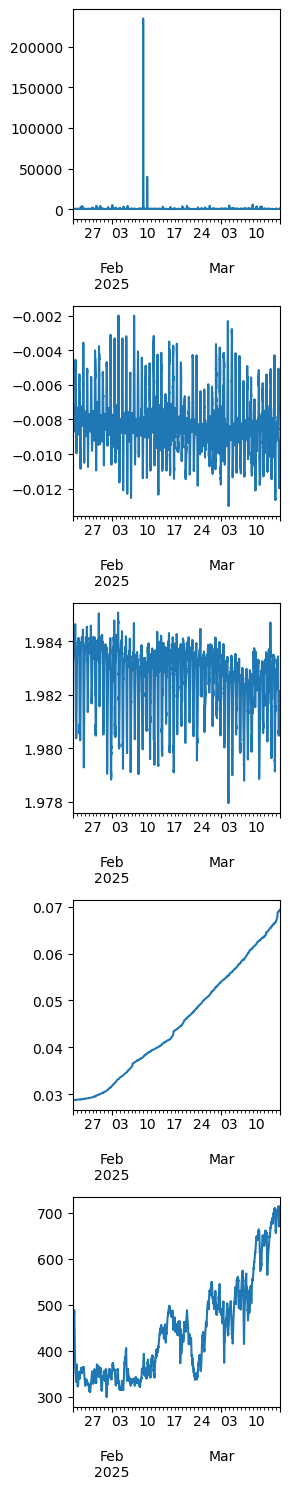

In [9]:
# plot
vars = []
for station in ['VPCC']:
    for channel in ['Z']:
        vars.append(interpolated[f'{station}{channel} RSAM'])
for station in ['VPRS']:
    for channel in ['E', 'N', 'Z']:
        vars.append(interpolated[f'{station} Field {channel}'])
vars.append(interpolated['CO2 concentration'])

scale=3
fig, ax = plt.subplots(len(vars), figsize=(scale, scale*len(vars)))

for ii, v in enumerate(vars):
    v.plot(ax=ax[ii])

fig.tight_layout()